# 📦 Brazilian E-Commerce 데이터를 통한 라스트마일 & 고객 만족도 분석

> **데이터**: Kaggle · Brazilian E-Commerce Public Dataset by Olist  
> **핵심 질문**: 배송 지연이 고객 만족도와 재구매에 얼마나 영향을 주는가?  
> **AARRR 선정**: **Retention(재구매)** & **Revenue(매출/LTV)**

---

## 📋 목차
```
STEP 0.  환경 설정 — 라이브러리 임포트 & 스타일
STEP 1.  데이터 로딩 — pd.read_csv()로 8개 테이블 불러오기
STEP 2.  데이터 이해 — ERD 구조 파악, 기초 확인
STEP 3.  테이블 조인 — 마스터 테이블 만들기
STEP 4.  전처리 — 날짜 변환, 파생변수 생성, 결측치 처리
STEP 5.  EDA — 분포, 추이, 결측치 시각화
STEP 6.  AARRR 선정 근거 — 왜 Retention & Revenue인가
STEP 7.  라스트마일 배송 분석 — 지연 패턴, 지역/카테고리
STEP 8.  고객 만족도 분석 — 리뷰 분포, NPS
STEP 9. 코호트 & 리텐션 분석
STEP 10. LTV 분석 — 배송 경험별 생애 가치
STEP 11. 퍼널 분석 — 만족도 흐름
STEP 12. 인사이트 & 액션 플랜
```


---
## STEP 0 환경 설정

분석에 필요한 라이브러리 import를 불러옵니다.

In [47]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

In [69]:
import matplotlib.font_manager as fm

# Mac 기본 한글 폰트
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [67]:
# ── pandas 출력 옵션 ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 30)          # 컬럼이 많아도 가로로 다 보여주기
pd.set_option('display.float_format', '{:.2f}'.format)  # 소수점 2자리 고정

# ── 차트 공통 스타일 ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize'   : (13, 5),
    'figure.dpi'       : 110,
    'axes.spines.top'  : False,    # 위쪽 테두리 제거 → 더 깔끔하게
    'axes.spines.right': False,
    'font.size'        : 11,
})

# 자주 쓸 색상
C_BLUE = '#378ADD'
C_OK   = '#1D9E75'   # 온타임 → 초록
C_LATE = '#E24B4A'   # 지연   → 빨강

---
## STEP 1 - 데이터 로딩

pd.read_csv()`로 8개 CSV 파일을 불러옵니다.  
파일명이 길어서 딕셔너리로 한 번에 처리합니다.

In [48]:
DATA_DIR = "Data"

dfs = {
    'orders': orders, 'customers': customers, 'items': items,
    'reviews': reviews, 'products': products, 'sellers': sellers, 'payments': payments
}
orders    = pd.read_csv(os.path.join(DATA_DIR, "olist_orders_dataset.csv"))
customers = pd.read_csv(os.path.join(DATA_DIR, "olist_customers_dataset.csv"))
items     = pd.read_csv(os.path.join(DATA_DIR, "olist_order_items_dataset.csv"))
reviews   = pd.read_csv(os.path.join(DATA_DIR, "olist_order_reviews_dataset.csv"))
products  = pd.read_csv(os.path.join(DATA_DIR, "olist_products_dataset.csv"))
sellers   = pd.read_csv(os.path.join(DATA_DIR, "olist_sellers_dataset.csv"))
payments  = pd.read_csv(os.path.join(DATA_DIR, "olist_order_payments_dataset.csv"))
geo       = pd.read_csv(os.path.join(DATA_DIR, "olist_geolocation_dataset.csv"))
cat_name   = pd.read_csv(os.path.join(DATA_DIR, "product_category_name_translation.csv"))

print("완료!")

완료!


## STEP 2 - 데이터 이해

분석하기 전에 각 테이블이 어떤 정보를 담고 있는지 먼저 파악합니다.

### 테이블 관계도 (ERD)
```
[customers] ──customer_id──▶ [orders] ──order_id──▶ [order_items] ──product_id──▶ [products]
                                │                          │
                                │                    seller_id ──▶ [sellers]
                                ├──order_id──▶ [order_payments]
                                └──order_id──▶ [order_reviews]
```

**핵심 테이블**: `orders` — 모든 분석의 중심축

| 컬럼 | 의미 |
|------|------|
| `order_purchase_timestamp` | 고객이 주문한 시각 |
| `order_delivered_customer_date` | 고객이 실제 수령한 날짜 |
| `order_estimated_delivery_date` | 시스템이 약속한 배송 완료일 |
| `order_status` | 주문 상태 (delivered / shipped / canceled 등) |


In [49]:
# ── orders 테이블 --
print('=== orders 컬럼 목록 ===')
print(orders.dtypes)   # 각 컬럼의 데이터 타입 확인
print()
orders.head()          # 상위 5행 미리보기

=== orders 컬럼 목록 ===
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object



,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [50]:
# ── 결측치 현황 확인 ─────────────────────────────────────────────────────────
# isnull().sum() : 컬럼별 결측치(NaN) 개수
print('=== 결측치가 있는 컬럼만 표시 ===')
for name, df in dfs.items():
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    if len(miss) > 0:
        print(f'\n[{name}]')
        for col, cnt in miss.items():
            print(f'  {col}: {cnt:,}개 ({cnt/len(df)*100:.1f}%)')
    else:
        print(f'[{name}] 결측치 없음')

=== 결측치가 있는 컬럼만 표시 ===

[orders]
  order_approved_at: 160개 (0.2%)
  order_delivered_carrier_date: 1,783개 (1.8%)
  order_delivered_customer_date: 2,965개 (3.0%)
[customers] 결측치 없음
[items] 결측치 없음

[reviews]
  review_comment_title: 87,656개 (88.3%)
  review_comment_message: 58,247개 (58.7%)

[products]
  product_category_name: 610개 (1.9%)
  product_name_lenght: 610개 (1.9%)
  product_description_lenght: 610개 (1.9%)
  product_photos_qty: 610개 (1.9%)
  product_weight_g: 2개 (0.0%)
  product_length_cm: 2개 (0.0%)
  product_height_cm: 2개 (0.0%)
  product_width_cm: 2개 (0.0%)
[sellers] 결측치 없음
[payments] 결측치 없음


---
## STEP 3 · 테이블 조인 — 마스터 테이블 만들기

여러 테이블을 `order_id` 또는 `customer_id` 기준으로 합쳐서
분석에 필요한 정보가 **한 행에 모두 담긴** 마스터 테이블을 만듭니다.

> 💡 `merge()` = SQL의 JOIN과 같습니다  
> `how='left'` = 왼쪽 테이블 기준으로 합치기 (없는 값은 NaN)

In [51]:
# ── STEP 3-1: 배송 완료 주문만 필터링 ───────────────────────────────────────
# 배송이 완료돼야 '실제 배송일'이 존재합니다
# 취소/배송 중인 주문은 지연 분석 대상이 아닙니다
delivered = orders[orders['order_status'] == 'delivered'].copy()

print(f'전체 주문: {len(orders):,}건')
print(f'배송 완료: {len(delivered):,}건 ({len(delivered)/len(orders)*100:.1f}%)')
print(f'제외됨:   {len(orders)-len(delivered):,}건 (취소/배송중 등)')

전체 주문: 99,441건
배송 완료: 96,478건 (97.0%)
제외됨:   2,963건 (취소/배송중 등)


In [52]:
# ── STEP 3-2: 리뷰 테이블 조인 ──────────────────────────────────────────────
# 같은 주문에 리뷰가 여러 개인 경우 → 점수 평균 사용
review_agg = (
    reviews
    .groupby('order_id')['review_score']
    .mean()
    .reset_index()
)

master = delivered.merge(review_agg, on='order_id', how='left')
print(f'리뷰 조인 후: {len(master):,}행  리뷰 있는 주문: {master["review_score"].notna().sum():,}건')

리뷰 조인 후: 96,478행  리뷰 있는 주문: 95,832건


In [53]:
# ── STEP 3-3: 고객 정보 조인 ────────────────────────────────────────────────
# customer_id       : 주문마다 새로 발급 (같은 사람도 다를 수 있음)
# customer_city         : 고객이 등록한 도시 (배송지 아님) -> 도시별 배송 지연 분석에서 사용
# customer_unique_id: 실제 사람을 구분하는 식별자 → 코호트 분석에서 사용
master = master.merge(
    customers[['customer_id', 'customer_unique_id','customer_city','customer_state']],
    on='customer_id',
    how='left'
)

In [54]:
# ── STEP 3-4: 주문 금액 집계 후 조인 ────────────────────────────────────────
# items 테이블: 주문 1건에 상품이 여러 개일 수 있어서 order_id로 묶어서 합산
# shipping_limit_date: 판매자 발송 기한 (min = 가장 빠른 기한 기준)
order_value = (
    items
    .groupby('order_id')
    .agg(
        order_value   = ('price', 'sum'),           # 상품 가격 합계
        freight_value = ('freight_value', 'sum'),   # 배송비 합계
        item_count    = ('order_item_id', 'count'), # 상품 개수
        shipping_limit_date = ('shipping_limit_date', 'min')  # 가장 빠른 발송 기한
    )
    .reset_index()
)
master = master.merge(order_value, on='order_id', how='left')

In [55]:
# ── STEP 3-5: 결제 정보 조인 ────────────────────────────────────────────────
# 한 주문에 결제 방법이 여러 개일 수 있어서 대표값(첫 번째 행)만 사용
pay_main = payments.drop_duplicates('order_id')[['order_id', 'payment_type', 'payment_installments']]
master = master.merge(pay_main, on='order_id', how='left')


In [56]:
# ── STEP 3-6: 상품 카테고리 조인 ────────────────────────────────────────────
#  신규 추가: items → products → cat_name 순서로 연결
# 주문에 상품이 여러 개면 첫 번째 상품의 카테고리를 대표값으로 사용
item_category = (
    items[['order_id', 'product_id']]
    .drop_duplicates('order_id')                        # 주문당 1행
    .merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
    .merge(cat_name, on='product_category_name', how='left')  # 영문 카테고리명
    [['order_id', 'product_category_name', 'product_category_name_english']]  # product_category_name_english = 영문명
    .rename(columns={'product_category_name_english': 'category_en'})
)
master = master.merge(item_category, on='order_id', how='left')

print(f'\n✅ 마스터 테이블 완성: {len(master):,}행 × {master.shape[1]}컬럼')
print('컬럼 목록:')
print(master.columns.tolist())


✅ 마스터 테이블 완성: 96,478행 × 20컬럼
컬럼 목록:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'review_score', 'customer_unique_id', 'customer_city', 'customer_state', 'order_value', 'freight_value', 'item_count', 'shipping_limit_date', 'payment_type', 'payment_installments', 'product_category_name', 'category_en']


---
## STEP 4 - 전처리 (날짜 변환 & 파생변수 생성)


| 파생변수 | 계산 방법 | 의미 |
|----------|-----------|------|
| `delivery_delay_days` | delivered - estimated | 지연 일수 |
| `is_delayed` | delay_days > 0 | 지연 여부 (True/False) |
| `delay_bucket` |  | 지연구간 |
| `actual_delivery_days` | delivered - purchase | 실제 배송 소요일 |
| `seller_late` | carrier_date > shipping_limit_date | 판매자 발송 지연 여부 |
| `purchase_month` | 주문일의 연월 | 코호트 분석용 |
| `is_repurchase` | customer_unique_id 주문 횟수 > 1 | 재구매 여부 |


In [57]:
# ── 날짜 컬럼을 문자열 → datetime 타입으로 변환 ──────────────────────────────
# errors='coerce': 변환 실패 시 에러 대신 NaT(= 날짜 없음)으로 처리
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date',
]
for col in date_cols:
    master[col] = pd.to_datetime(master[col], errors='coerce')

print('날짜 타입 변환 완료:')
print(master[date_cols].dtypes)

날짜 타입 변환 완료:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
shipping_limit_date              datetime64[ns]
dtype: object


In [61]:
# ── 파생변수 생성 ────────────────────────────────────────────────────────────

# 실제 배송 소요일: 날짜 차이를 구하면 timedelta가 나옴 → .dt.days로 '일' 단위 정수 추출
master['delivery_days_actual'] = (
    master['order_delivered_customer_date'] - master['order_purchase_timestamp']
).dt.days

# 예상 배송 소요일
master['delivery_days_estimated'] = (
    master['order_estimated_delivery_date'] - master['order_purchase_timestamp']
).dt.days

# 지연일: 양수면 늦게 도착, 음수면 일찍 도착
master['delivery_delay_days'] = (
    master['delivery_days_actual'] - master['delivery_days_estimated']
)

# 지연 여부 (True/False)
master['is_late'] = master['delivery_delay_days'] > 0

# 지연 여부 — 판매자가 기한 내에 택배사에 넘겼는지 확인
master['is_seller_late'] = (
    master['order_delivered_carrier_date'] > master['shipping_limit_date']
)


# 구매 연월 (코호트 분석에서 사용)
master['purchase_month'] = master['order_purchase_timestamp'].dt.to_period('M')

# 재구매 여부
master['is_repeat_customer'] = master.duplicated('customer_unique_id', keep=False)

# 이상치 제거: 배송일이 음수거나 비정상적으로 큰 행 제거
master = master[
    (master['delivery_days_actual'] > 0) &
    (master['delivery_days_actual'] < 120)
].copy()

print('✅ 파생변수 생성 완료')
master[['delivery_days_actual', 'delivery_days_estimated',
         'delivery_delay_days', 'is_late']].describe()

✅ 파생변수 생성 완료


,delivery_days_actual,delivery_days_estimated,delivery_delay_days
count,96414.000000,96414.000000,96414.000000
mean,12.028367,23.371035,-11.342668
std,8.996976,8.757191,9.716145
min,1.000000,2.000000,-146.000000
25%,6.000000,18.000000,-16.000000
50%,10.000000,23.000000,-12.000000
75%,15.000000,28.000000,-7.000000
max,118.000000,155.000000,105.000000


In [60]:
# ── 지연 구간 컬럼 추가 ──────────────────────────────────────────────────────
# pd.cut(): 연속 숫자를 구간 레이블로 변환
master['delay_bucket'] = pd.cut(
    master['delivery_delay_days'],
    bins=[-999, -10, -5, 0, 3, 7, 14, 999],
    labels=['10일+ 일찍', '5-10일 일찍', '5일 내 일찍', '정시', '1-3일 지연', '4-7일 지연', '7일+ 지연']
)

print('지연 구간별 주문 수:')
print(master['delay_bucket'].value_counts().sort_index())

지연 구간별 주문 수:
delay_bucket
10일+ 일찍     59080
5-10일 일찍    21663
5일 내 일찍      8407
정시           2354
1-3일 지연      1795
4-7일 지연      1667
7일+ 지연       1448
Name: count, dtype: int64


In [63]:
# 라스트마일 소요일 (택배사 인수 → 고객 수령)
master['last_mile_days'] = (
    master['order_delivered_customer_date'] - master['order_delivered_carrier_date']
).dt.days

# 라스트마일 구간
master['last_mile_bucket'] = pd.cut(
    master['last_mile_days'],
    bins=[0, 3, 7, 14, 999],
    labels=['3일 이내', '4-7일', '8-14일', '14일+']
)

# 라스트마일 소요일이 음수거나 60일 이상인 이상치 제거
master = master[
    (master['last_mile_days'] > 0) &
    (master['last_mile_days'] < 60)
].copy()

print('라스트마일 구간별 주문 수:')
print(master['last_mile_bucket'].value_counts().sort_index())

라스트마일 구간별 주문 수:
last_mile_bucket
3일 이내    20223
4-7일     32014
8-14일    26470
14일+     14830
Name: count, dtype: int64


---
## STEP 5 - EDA — 탐색적 데이터 분석

데이터의 전체적인 분포와 패턴을 파악합니다.  
"데이터가 어떻게 생겼는지" 눈으로 먼저 확인하는 단계입니다.


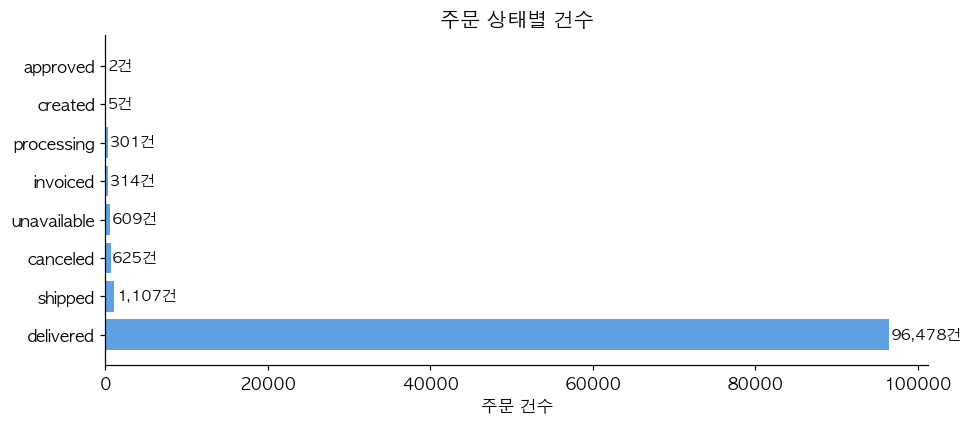

In [70]:
# ── 5-1: 주문 상태 분포 ──────────────────────────────────────────────────────
status_counts = orders['order_status'].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(status_counts.index, status_counts.values, color=C_BLUE, alpha=0.8)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 200, bar.get_y() + bar.get_height()/2,
            f'{w:,.0f}건', va='center', fontsize=10)
ax.set_title('주문 상태별 건수', fontweight='bold')
ax.set_xlabel('주문 건수')
plt.tight_layout()
plt.show()


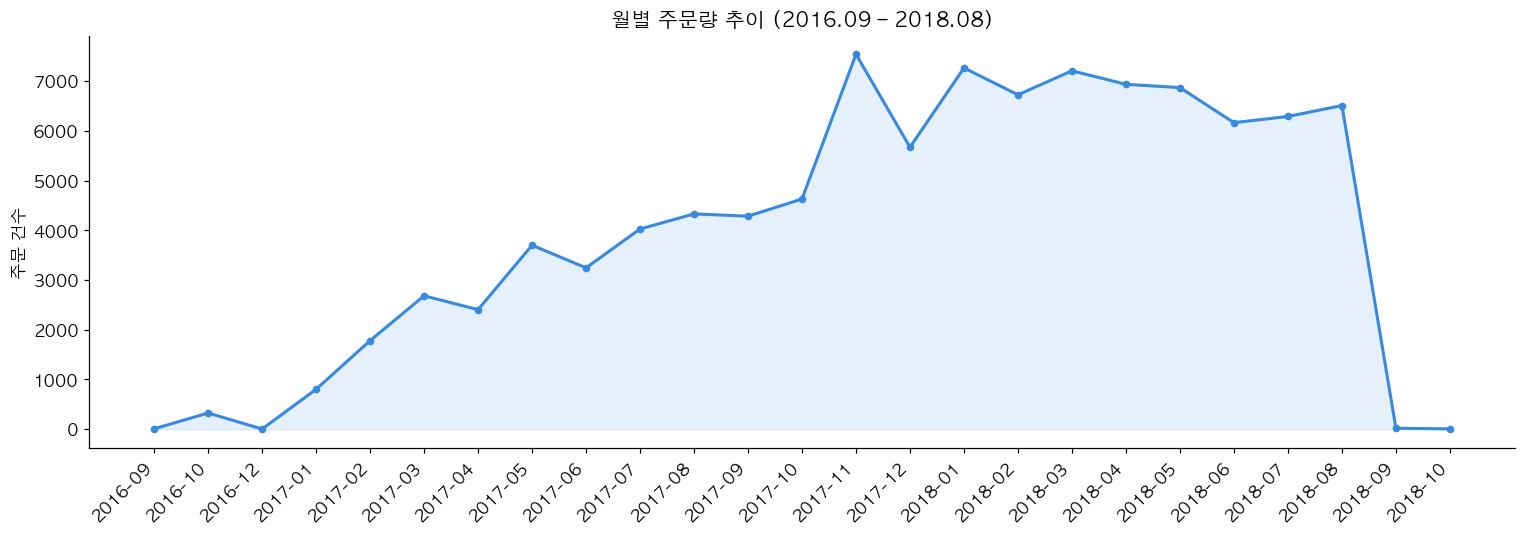

분석 기간: 2016-09 ~ 2018-10
월 최고 주문량: 7,544건 (2017-11)


In [72]:
# ── 5-2: 월별 주문량 추이 ────────────────────────────────────────────────────
orders['purchase_month'] = pd.to_datetime(
    orders['order_purchase_timestamp'], errors='coerce'
).dt.to_period('M')

monthly = orders.groupby('purchase_month').size().reset_index(name='count')
monthly['purchase_month'] = monthly['purchase_month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['purchase_month'], monthly['count'],
        marker='o', markersize=4, color=C_BLUE, linewidth=2)
ax.fill_between(monthly['purchase_month'], monthly['count'], alpha=0.12, color=C_BLUE)
plt.xticks(rotation=45, ha='right')
ax.set_title('월별 주문량 추이 (2016.09 – 2018.08)', fontweight='bold')
ax.set_ylabel('주문 건수')
plt.tight_layout()
plt.show()

print(f'분석 기간: {monthly["purchase_month"].min()} ~ {monthly["purchase_month"].max()}')
print(f'월 최고 주문량: {monthly["count"].max():,}건 ({monthly.loc[monthly["count"].idxmax(), "purchase_month"]})')


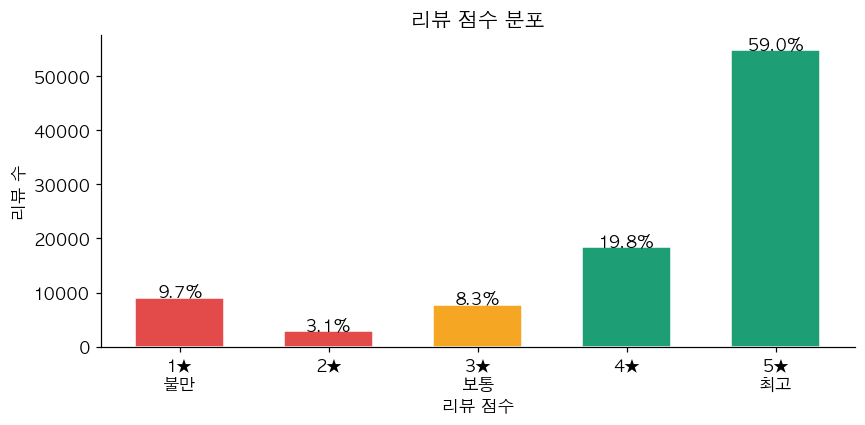

In [79]:
# ── 5-3: 리뷰 점수 분포 ──────────────────────────────────────────────────────
# review_score를 정수로 변환 후 집계
score_counts = master['review_score'].dropna().astype(int).value_counts().sort_index()
score_pct    = (score_counts / score_counts.sum() * 100).round(1)

bar_colors = [C_LATE, C_LATE, '#F5A623', C_OK, C_OK]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(score_counts.index, score_counts.values,
              color=bar_colors, width=0.6, edgecolor='white')
for bar, pct in zip(bars, score_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{pct}%', ha='center', fontsize=11, fontweight='bold')

ax.set_title('리뷰 점수 분포', fontweight='bold')
ax.set_xlabel('리뷰 점수')
ax.set_ylabel('리뷰 수')
ax.set_xticks([1,2,3,4,5])
ax.set_xticklabels(['1★\n불만', '2★', '3★\n보통', '4★', '5★\n최고'])
plt.tight_layout()
plt.show()

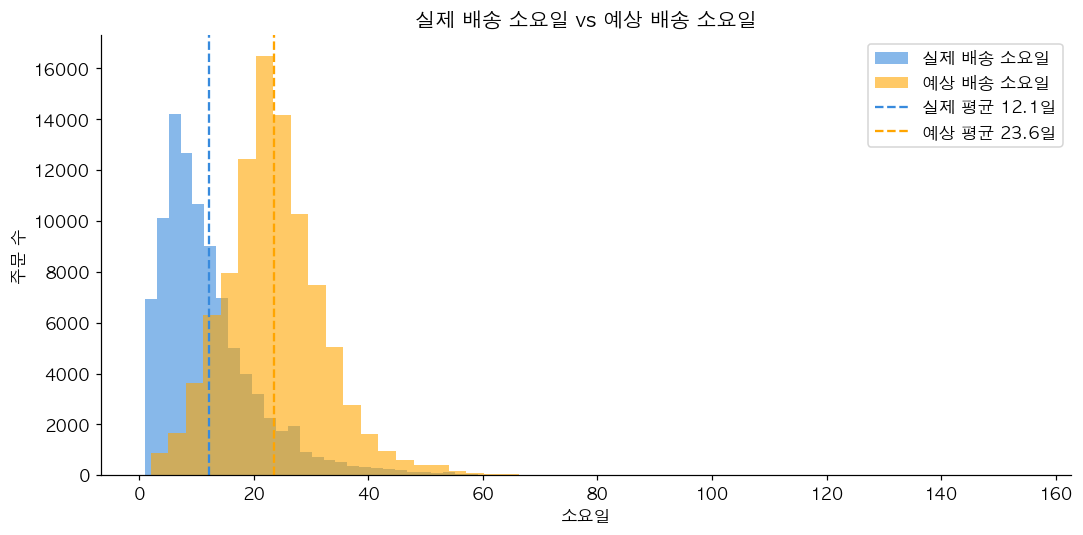

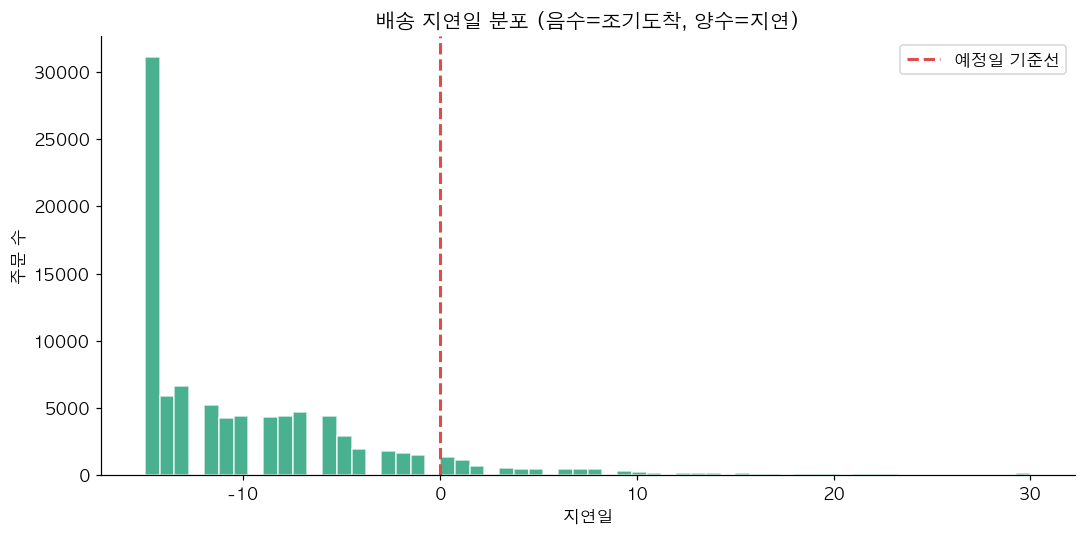

조기 도착: 91.0%
정시 도착: 1.4%
지연 도착: 7.5%


In [88]:
# ── 5-4: 라스트마일 소요일 분포 ──────────────────────────────────────────────

# 실제 소요일 vs 예상 소요일 분포 비교
plt.figure(figsize=(10, 5))
plt.hist(master['delivery_days_actual'].dropna(), bins=50, 
         color=C_BLUE, alpha=0.6, label='실제 배송 소요일')
plt.hist(master['delivery_days_estimated'].dropna(), bins=50, 
         color='orange', alpha=0.6, label='예상 배송 소요일')
plt.axvline(master['delivery_days_actual'].mean(), color=C_BLUE, 
            linestyle='--', label=f'실제 평균 {master["delivery_days_actual"].mean():.1f}일')
plt.axvline(master['delivery_days_estimated'].mean(), color='orange', 
            linestyle='--', label=f'예상 평균 {master["delivery_days_estimated"].mean():.1f}일')
plt.title('실제 배송 소요일 vs 예상 배송 소요일', fontweight='bold')
plt.xlabel('소요일')
plt.ylabel('주문 수')
plt.legend()
plt.tight_layout()
plt.show()

# 지연/정시/조기 도착 분포
delay_clipped = master['delivery_delay_days'].dropna().clip(-15, 30)

plt.figure(figsize=(10, 5))
plt.hist(delay_clipped, bins=60, color=C_OK, alpha=0.8, edgecolor='white')
plt.axvline(0, color=C_LATE, linestyle='--', linewidth=2, label='예정일 기준선')
plt.title('배송 지연일 분포 (음수=조기도착, 양수=지연)', fontweight='bold')
plt.xlabel('지연일')
plt.ylabel('주문 수')
plt.legend()
plt.tight_layout()
plt.show()

early = (master['delivery_delay_days'] < 0).sum()
ontime = (master['delivery_delay_days'] == 0).sum()
late = (master['delivery_delay_days'] > 0).sum()
total = len(master)
print(f'조기 도착: {early/total*100:.1f}%')
print(f'정시 도착: {ontime/total*100:.1f}%')
print(f'지연 도착: {late/total*100:.1f}%')

In [ ]:

# 라스트마일 소요일 히스토그램
plt.figure(figsize=(10, 5))
plt.hist(master['last_mile_days'].dropna(), bins=50, color=C_BLUE, alpha=0.8, edgecolor='white')
plt.axvline(mean_lm, color='red', linestyle='--', label=f'평균 {mean_lm:.1f}일')
plt.title('라스트마일 소요일 분포', fontweight='bold')
plt.xlabel('소요일')
plt.legend()
plt.tight_layout()
plt.show()

# 라스트마일 구간별 주문 수
plt.figure(figsize=(10, 5))
plt.bar(bucket_counts.index, bucket_counts.values, color=C_BLUE, alpha=0.8)
plt.title('라스트마일 구간별 주문 수', fontweight='bold')
plt.xlabel('구간')
plt.ylabel('주문 수')
plt.tight_layout()
plt.show()

late_rate = master['is_late'].mean()
print(f'전체 지연 배송률: {late_rate*100:.1f}%')
print(f'라스트마일 평균 소요일: {mean_lm:.1f}일')



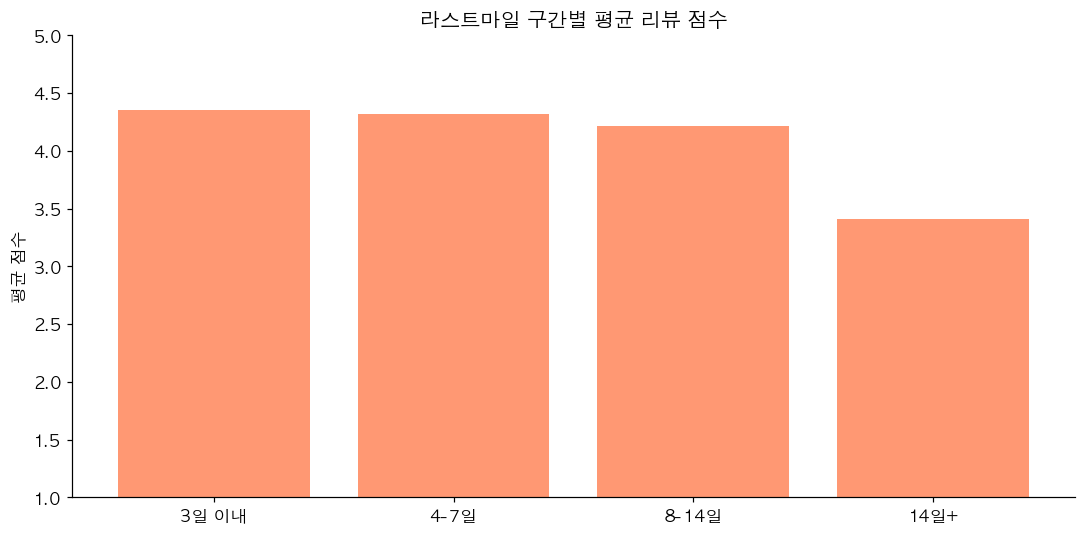

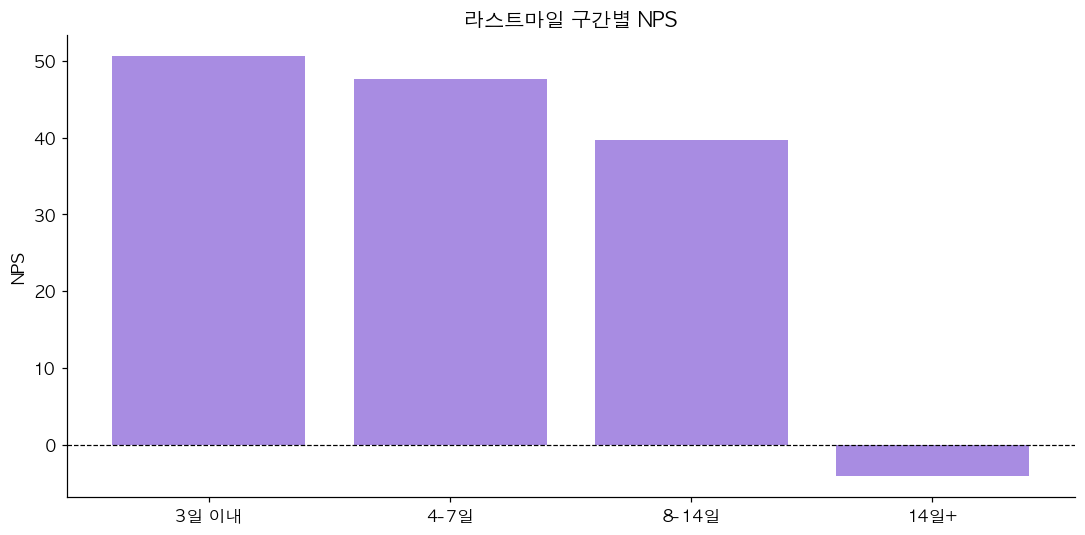

In [84]:
# ── 5-5: 라스트마일 × 만족도 ─────────────────────────────────────────────────
def calc_nps(df):
    total     = df['review_score'].notna().sum()
    promoter  = (df['review_score'] == 5).sum()
    detractor = (df['review_score'] <= 3).sum()
    return (promoter - detractor) / total * 100

score_by_bucket = master.groupby('last_mile_bucket')['review_score'].mean()
plt.figure(figsize=(10, 5))
plt.bar(score_by_bucket.index, score_by_bucket.values, color='coral', alpha=0.8)
plt.ylim(1, 5)
plt.title('라스트마일 구간별 평균 리뷰 점수', fontweight='bold')
plt.ylabel('평균 점수')
plt.tight_layout()
plt.show()

nps_by_bucket = master.groupby('last_mile_bucket').apply(calc_nps)
plt.figure(figsize=(10, 5))
plt.bar(nps_by_bucket.index, nps_by_bucket.values, color='mediumpurple', alpha=0.8)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('라스트마일 구간별 NPS', fontweight='bold')
plt.ylabel('NPS')
plt.tight_layout()
plt.show()

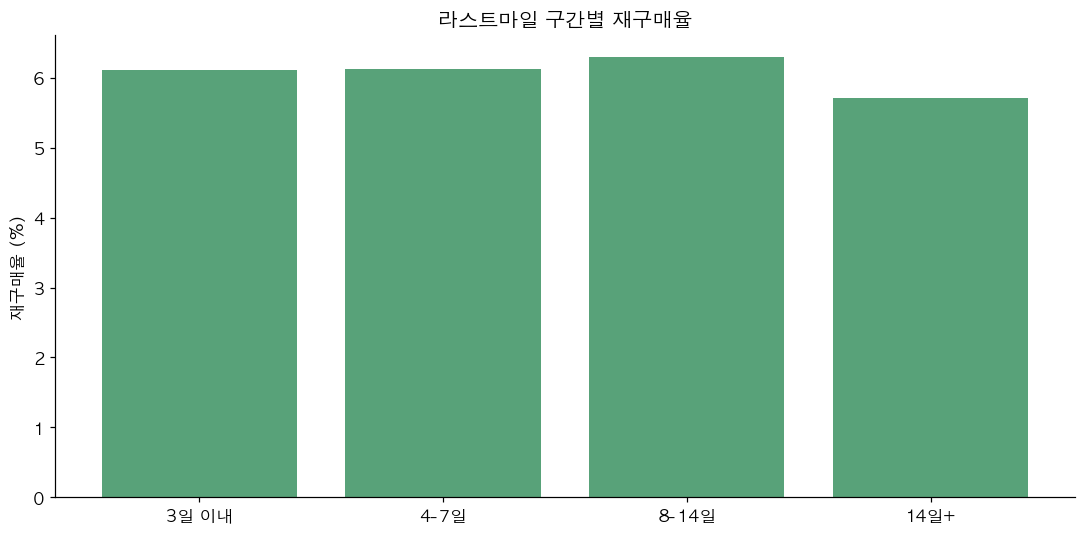

In [85]:
# ── 5-6: 라스트마일 × 재구매율 ───────────────────────────────────────────────
repurchase_by_bucket = master.groupby('last_mile_bucket')['is_repeat_customer'].mean() * 100

plt.figure(figsize=(10, 5))
plt.bar(repurchase_by_bucket.index, repurchase_by_bucket.values, color='seagreen', alpha=0.8)
plt.title('라스트마일 구간별 재구매율', fontweight='bold')
plt.ylabel('재구매율 (%)')
plt.tight_layout()
plt.show()

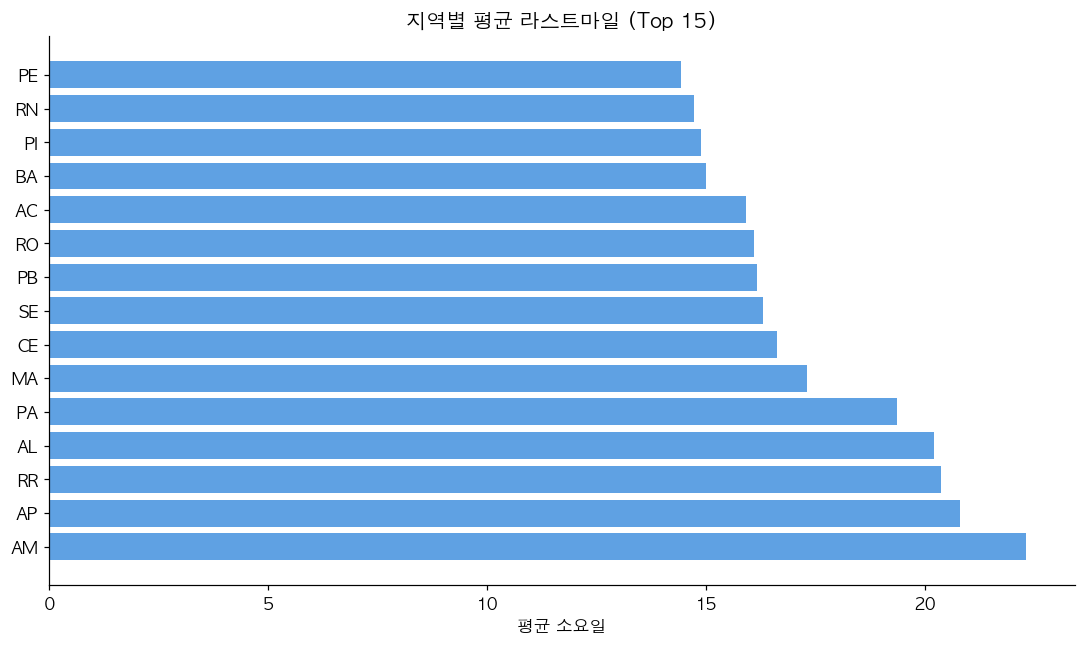

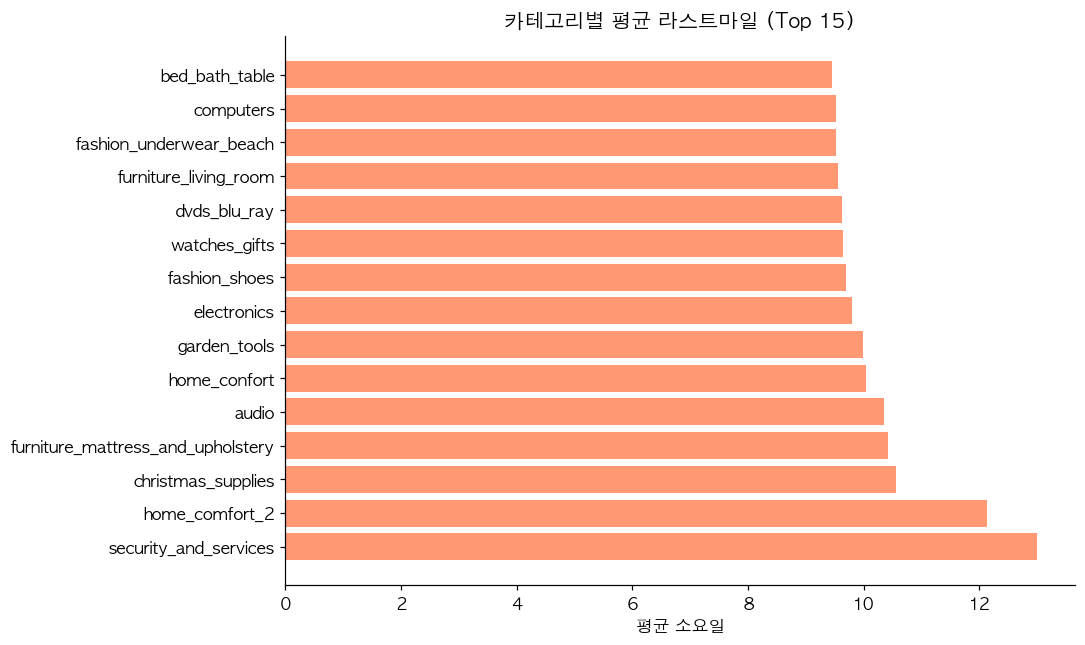

In [86]:
# ── 5-7: 지역 / 카테고리별 라스트마일 ────────────────────────────────────────
state_lm = master.groupby('customer_state')['last_mile_days'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
plt.barh(state_lm.index, state_lm.values, color=C_BLUE, alpha=0.8)
plt.title('지역별 평균 라스트마일 (Top 15)', fontweight='bold')
plt.xlabel('평균 소요일')
plt.tight_layout()
plt.show()

# 카테고리별 평균 라스트마일
cat_lm = master.groupby('category_en')['last_mile_days'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
plt.barh(cat_lm.index, cat_lm.values, color='coral', alpha=0.8)
plt.title('카테고리별 평균 라스트마일 (Top 15)', fontweight='bold')
plt.xlabel('평균 소요일')
plt.tight_layout()
plt.show()


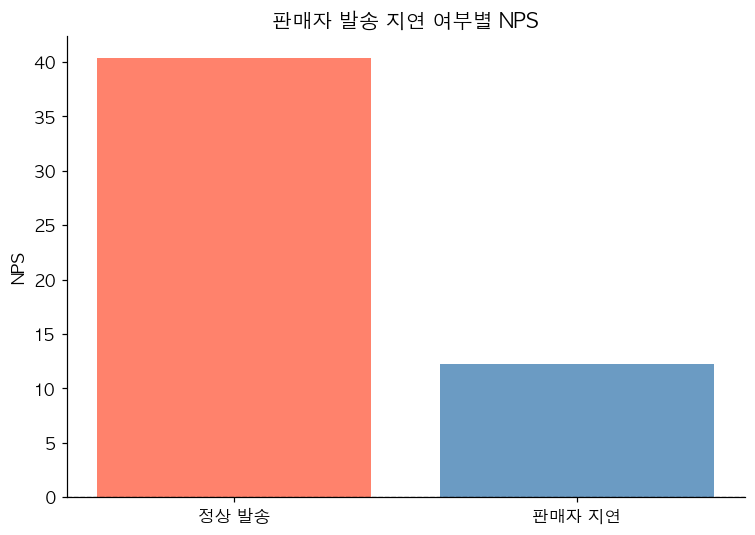

In [78]:
# ── 6-8: 판매자 지연 vs 물류 지연 ────────────────────────────────────────────
seller_nps = master.groupby('is_seller_late').apply(calc_nps).reset_index()
seller_nps.columns = ['is_seller_late', 'NPS']
seller_nps['label'] = seller_nps['is_seller_late'].map({True: '판매자 지연', False: '정상 발송'})

plt.figure(figsize=(7, 5))
plt.bar(seller_nps['label'], seller_nps['NPS'], color=['tomato', 'steelblue'], alpha=0.8)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('판매자 발송 지연 여부별 NPS', fontweight='bold')
plt.ylabel('NPS')
plt.tight_layout()
plt.show()